In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
titanic_df = pd.read_csv("../data/titanic.csv")

titanic_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Missing values

In [25]:
titanic_df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [26]:
titanic_df["age"] = titanic_df["age"].fillna(
    titanic_df["age"].median()
)

In [27]:
titanic_df["embarked"] = titanic_df["embarked"].fillna(
    titanic_df["embarked"].mode()[0]
)

In [28]:
titanic_df["embark_town"] = titanic_df["embark_town"].fillna(
    titanic_df["embark_town"].mode()[0]
)

drop unnecessary columns

In [29]:
titanic_df.drop("deck", axis=1, inplace=True)

In [30]:
titanic_df.drop(
    [
        "alive",
        "class",
        "who",
        "adult_male",
        "embark_town"
    ],
    axis=1,
    inplace=True
)

encoding

In [31]:
titanic_df["sex"] = titanic_df["sex"].map(
    {
        "male":0,
        "female":1
    }
)

In [32]:
titanic_df = pd.get_dummies(
    titanic_df,
    columns=["embarked"],
    drop_first=True
)

In [33]:
titanic_df["alone"] = titanic_df["alone"].astype(int)

training

In [34]:
X = titanic_df.drop("survived", axis=1)

y = titanic_df["survived"]

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [39]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [40]:
y_pred = rf_model.predict(X_test)

In [41]:
print(y_pred[:10])

[0 0 0 1 0 1 1 0 1 1]


In [42]:
from sklearn.metrics import accuracy_score

In [43]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8324022346368715


In [44]:
from sklearn.metrics import confusion_matrix

In [45]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[92, 13],
       [17, 57]])

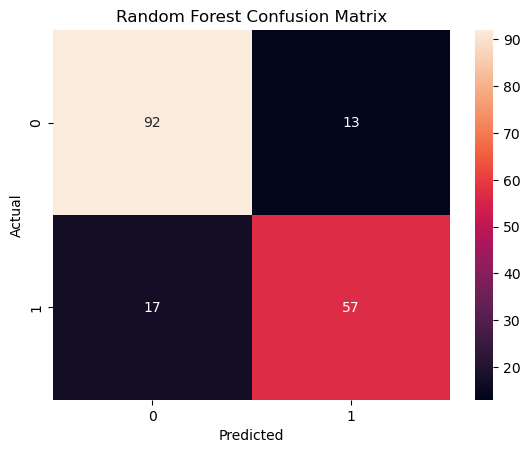

In [46]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
from sklearn.metrics import classification_report

In [48]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



feature importance

In [49]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance

,Feature,Importance
0,pclass,0.092493
1,sex,0.278978
2,age,0.248177
3,sibsp,0.041376
4,parch,0.028074
5,fare,0.262510
6,alone,0.015526
7,embarked_Q,0.009583
8,embarked_S,0.023283


In [50]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,sex,0.278978
5,fare,0.262510
2,age,0.248177
0,pclass,0.092493
3,sibsp,0.041376
4,parch,0.028074
8,embarked_S,0.023283
6,alone,0.015526
7,embarked_Q,0.009583


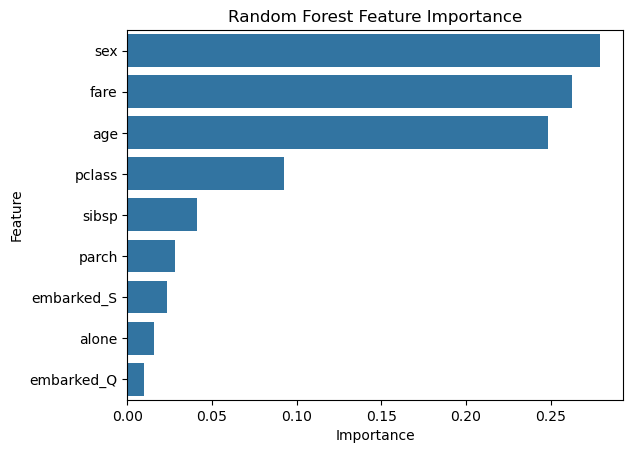

In [51]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.show()